# Host Environments and Retention

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

import numpy as np
import matplotlib.pyplot as plt
from gwGenealogy.hosts import (
    PlummerCluster,
    Mcl_rh_to_vescape, Mcl_rho_to_vescape,
    sample_star_clusters_mapelli2021,
    sample_escape_speed, escape_speed_cdf,
    compute_environment_retention, compute_multi_environment_retention,
    ENVIRONMENTS, GC_ENVIRONMENT, NSC_ENVIRONMENT
)
from gwGenealogy.utils import set_rcparams

set_rcparams()

lal.MSUN_SI != Msun


## Escape velocity formulas

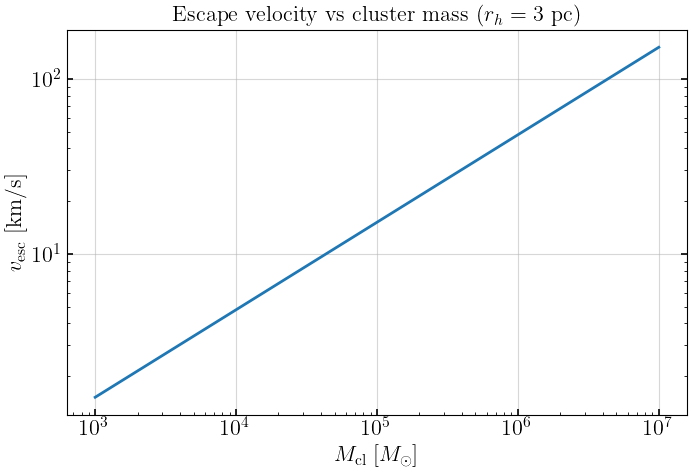

In [2]:
Mcl = np.logspace(3, 7, 100)
v_esc = Mcl_rh_to_vescape(Mcl, r_h=3.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(Mcl, v_esc, lw=2)
ax.set_xlabel(r'$M_{\rm cl}\;[M_\odot]$')
ax.set_ylabel(r'$v_{\rm esc}$ [km/s]')
ax.set_title('Escape velocity vs cluster mass ($r_h = 3$ pc)')
plt.show()

## Plummer cluster model

In [3]:
cluster = PlummerCluster(Mcl=1e6, r_h=3.0, cluster_type='GC')
print(cluster)
print(f"Escape speed:   {cluster.v_esc:.1f} km/s")
print(f"Core speed:      {cluster.v_core:.1f} km/s")
print(f"Scale radius:  {cluster.a:.2f} pc")

PlummerCluster(Mcl=1.00e+06, r_h=3.00, a=2.30, v_esc=61.2 km/s, v_core=33.1 km/s, r_t=15.0 pc, type=GC)
Escape speed:   61.2 km/s
Core speed:      33.1 km/s
Scale radius:  2.30 pc


## Merger retention in a Plummer cluster

In [4]:
v_kick = np.random.default_rng(42).uniform(0, 500, 1000)
cluster.merger_analysis(v_kick, M_bh=30.0)
print(f"P_ret  = {cluster.P_ret:.3f}")
print(f"P_core = {cluster.P_core:.3f}")
print(f"P_hier = {cluster.P_hier:.3f}")

P_ret  = 0.114
P_core = 0.068
P_hier = 0.011


## Cluster population sampling

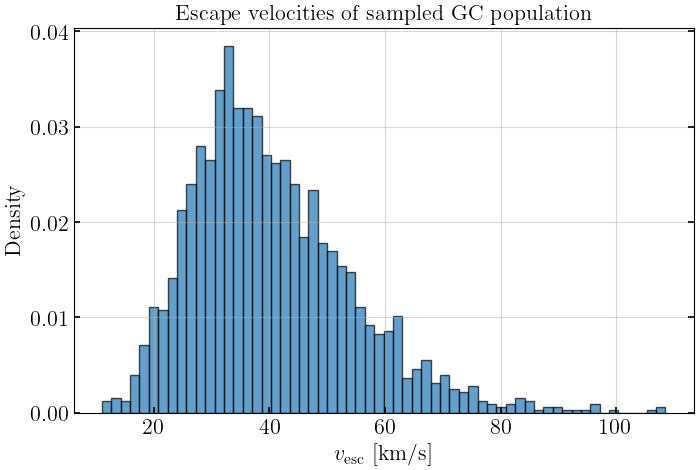

In [5]:
clusters = sample_star_clusters_mapelli2021(2000, cluster_type='GC', seed=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(clusters['v_esc'], bins=60, density=True, edgecolor='black', alpha=0.7)
ax.set_xlabel(r'$v_{\rm esc}$ [km/s]')
ax.set_ylabel('Density')
ax.set_title('Escape velocities of sampled GC population')
plt.show()

## Environment escape-speed distributions

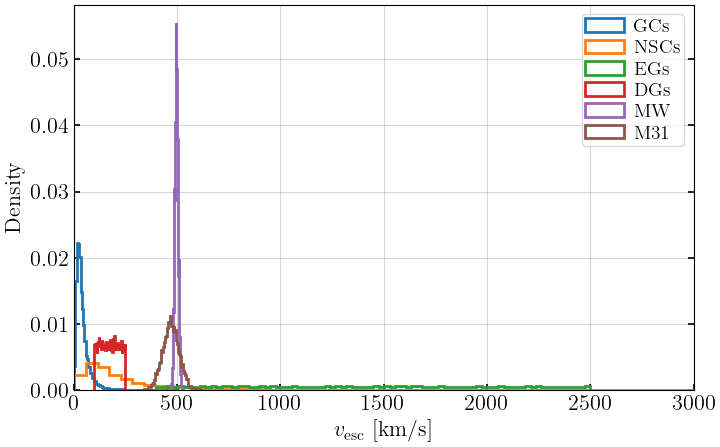

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, env in ENVIRONMENTS.items():
    v = sample_escape_speed(10000, env, seed=42)
    ax.hist(v, bins=80, density=True, histtype='step', lw=2, label=env['label'])
ax.set_xlabel(r'$v_{\rm esc}$ [km/s]')
ax.set_ylabel('Density')
ax.set_xlim(0, 3000)
ax.legend()
plt.show()

## Environment-marginalised retention

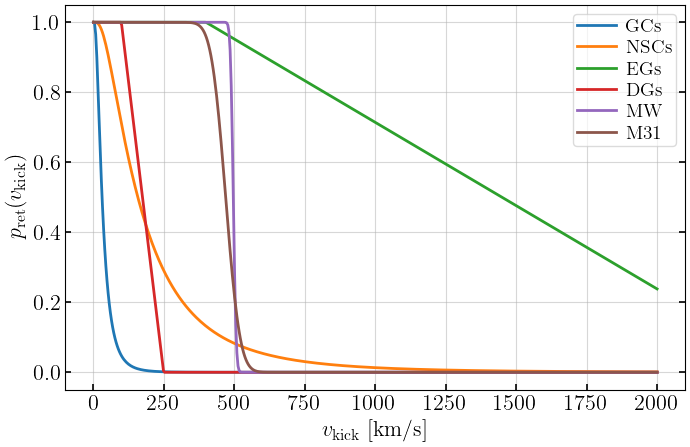

In [7]:
v_kick = np.linspace(1, 2000, 500)
fig, ax = plt.subplots(figsize=(8, 5))
for name, env in ENVIRONMENTS.items():
    p_ret = compute_environment_retention(v_kick, env)
    ax.plot(v_kick, p_ret, lw=2, label=env['label'])
ax.set_xlabel(r'$v_{\rm kick}$ [km/s]')
ax.set_ylabel(r'$p_{\rm ret}(v_{\rm kick})$')
ax.legend()
plt.show()

## Multi-environment retention

In [8]:
rng = np.random.default_rng(42)
v_kicks = rng.uniform(10, 500, 5000)
ret = compute_multi_environment_retention(v_kicks)
print("Environment-marginalised retention fractions:")
for name, p_ret_arr in ret.items():
    print(f"  {name}: <P_ret> = {p_ret_arr.mean():.3f}")

Environment-marginalised retention fractions:
  GC: <P_ret> = 0.061
  NSC: <P_ret> = 0.393
  EG: <P_ret> = 0.995
  DG: <P_ret> = 0.343
  MW: <P_ret> = 0.989
  M31: <P_ret> = 0.929
